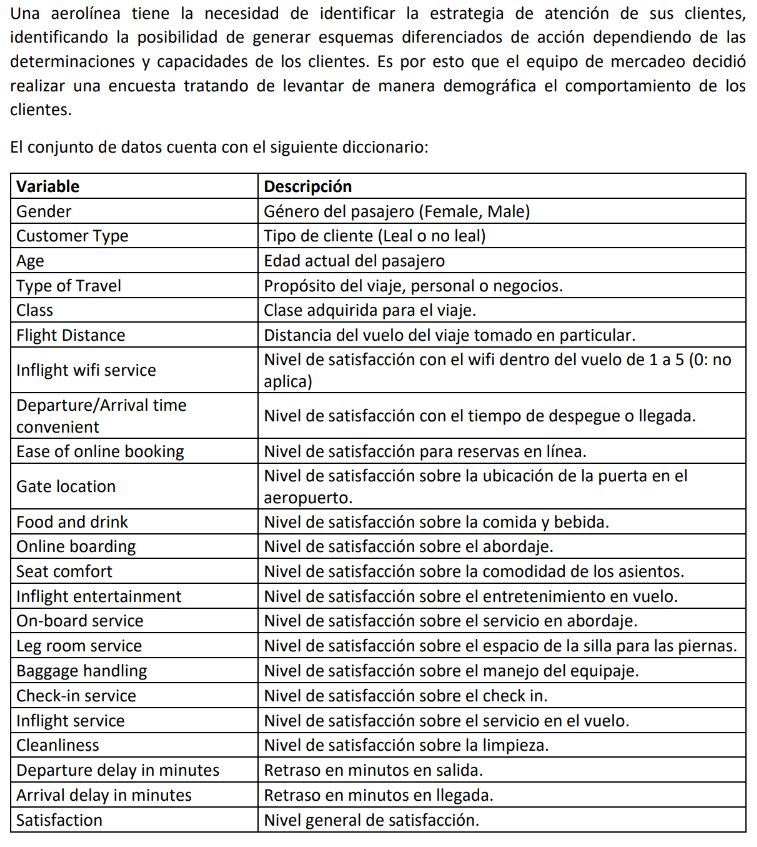

# Metodologia ASUM-DM
1. Entendimienot del negocio: Aerolinea que busca entender a sus clientes, su objetivo es entender las diferencias o particularidades de los clientes para ofrecer modelos o esquemas diferenciados de actuación.

2. Entendimiento analitico: Disenar un experimento que permita agrupa en una cantidad especifica de frupos a los cliente de la aerolinea, para que se puedan ofrecer modelos de atencion diferenciados.

3. Requerimentos de datos: Se requieren datos demograficos, servicio prestado al ususario, datos propios del negocio.

4. Recoleccion de datos: Encuesta a los clientes, datos de la aerolinea, datos de la industria.

5. Entendimiento de los datos: 
    - Identificar existencia de datos nulos. 
    - Exploracion univariada y multivariada.
    - Identificacion de correlaciones y multicolinealidad.


In [2]:

import pandas as pd
import numpy as np

#raficos
import matplotlib.pyplot as plt
import seaborn as sb


In [3]:
data =pd.read_csv('airline_loyalty.csv')
data

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,103899,94171,Female,disloyal Customer,23,Business travel,Eco,192,2,1,...,2,3,1,4,2,3,2,3,0.0,neutral or dissatisfied
103900,103900,73097,Male,Loyal Customer,49,Business travel,Business,2347,4,4,...,5,5,5,5,5,5,4,0,0.0,satisfied
103901,103901,68825,Male,disloyal Customer,30,Business travel,Business,1995,1,1,...,4,3,2,4,5,5,4,7,14.0,neutral or dissatisfied
103902,103902,54173,Female,disloyal Customer,22,Business travel,Eco,1000,1,1,...,1,4,5,1,5,4,1,0,0.0,neutral or dissatisfied


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

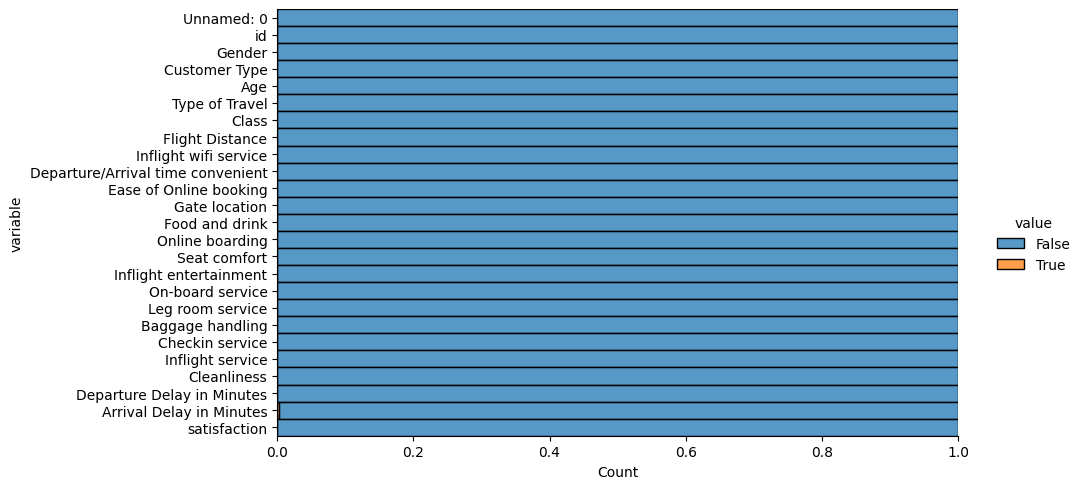

In [5]:
#Visualizar proporcion de valores nulos por variable
data.isnull().melt().pipe(lambda df: sb.displot(data = df, y = 'variable', hue = 'value', multiple = 'fill', aspect = 2))

Text(0.5, 0.98, 'Histograma de variables numéricas')

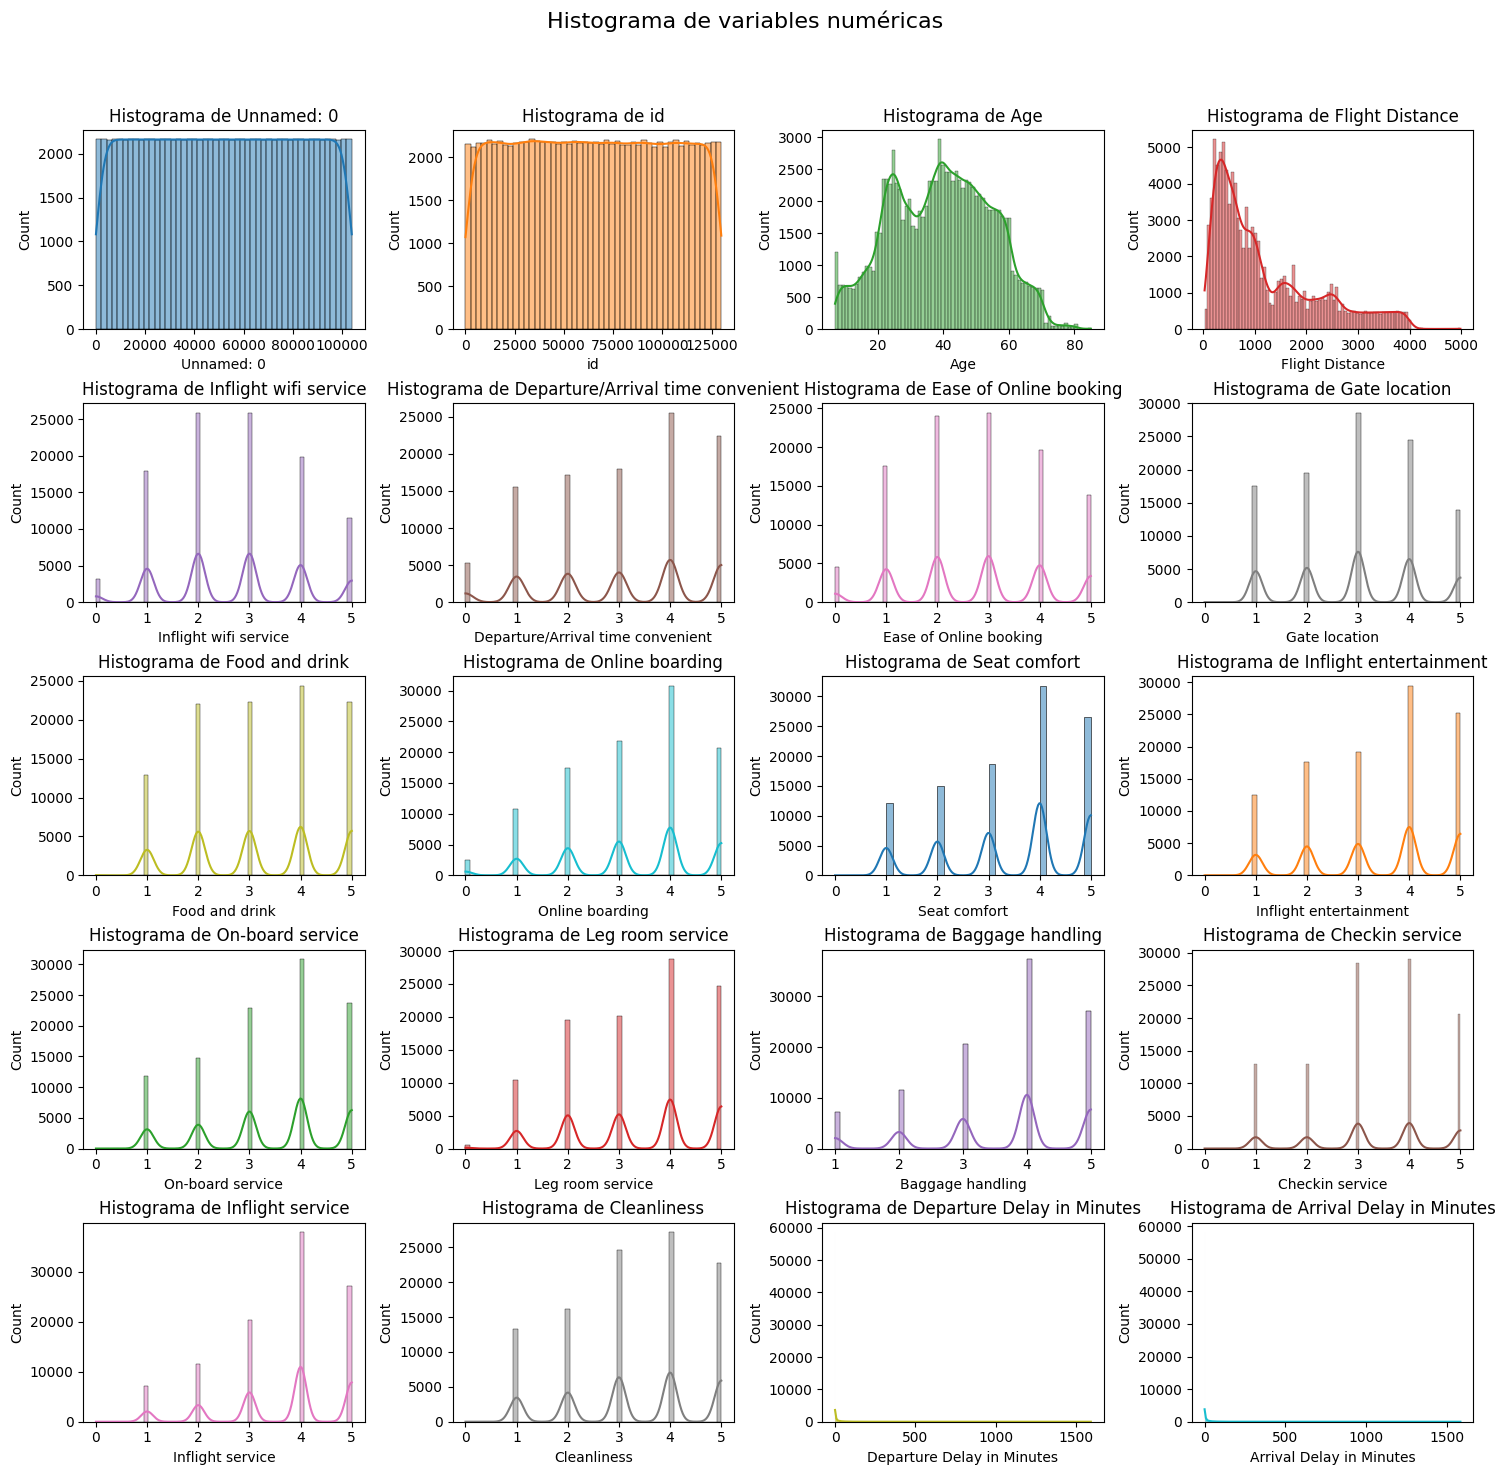

In [6]:
#Exploracion univariada
#Histograma de freuencias

fig, ax  = plt.subplots(5, 4, figsize=(15, 15))
ax = ax.flat
num_col = data.select_dtypes(include = ['int64', 'float64']).columns
for i, col in enumerate(num_col):
    sb.histplot(data = data, x = col,
                kde = True,
                color=list(sb.color_palette())[i % 10],
                ax = ax[i])
    ax[i].set_title(f'Histograma de {col}')
fig.tight_layout()
fig.subplots_adjust(top=0.9)
fig.suptitle('Histograma de variables numéricas', fontsize=16)

(0.0, 5000.0)

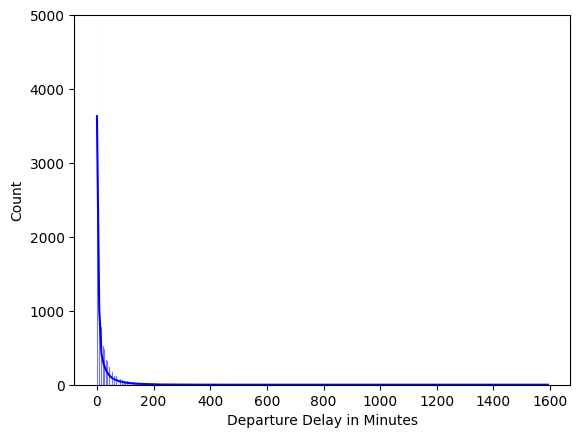

In [7]:
sb.histplot(data = data, x = data['Departure Delay in Minutes'], kde = True, color='blue')
plt.ylim(0,5000)

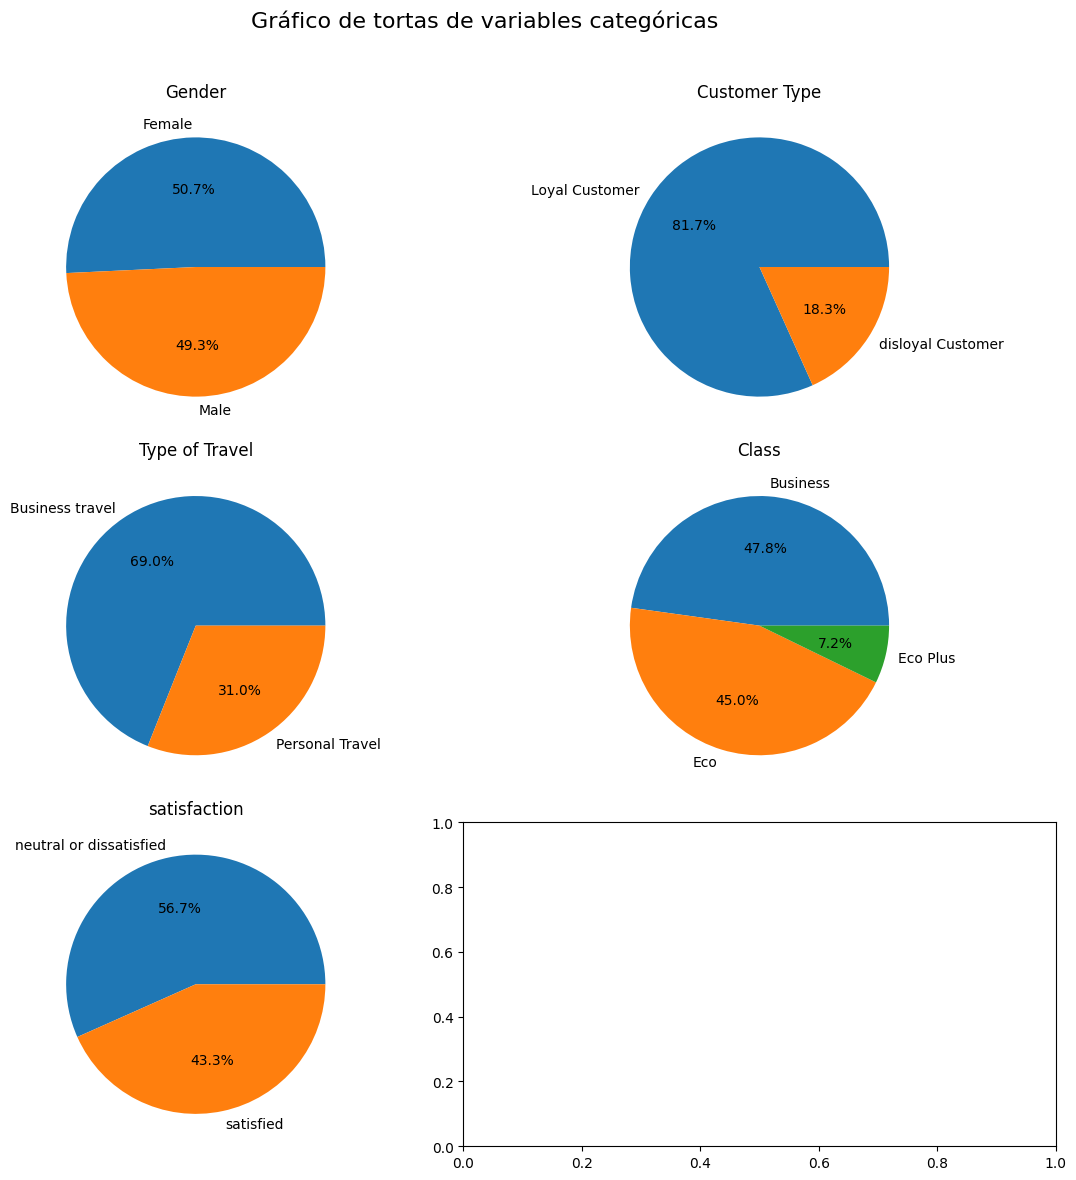

In [8]:
##Grafico de tortas
fig, ax = plt.subplots(3,2, figsize=(12, 12))
ax = ax.flat
cat_col = data.select_dtypes(include = ['object']).columns
for i, col in enumerate(cat_col):
    ax[i].pie(data[col].value_counts(), labels = data[col].value_counts().index, autopct='%0.1f%%',)
    ax[i].set_title(f'{col}')
fig.tight_layout()
fig.subplots_adjust(top=0.9)
fig.suptitle('Gráfico de tortas de variables categóricas', fontsize=16)
plt.show()

<Axes: >

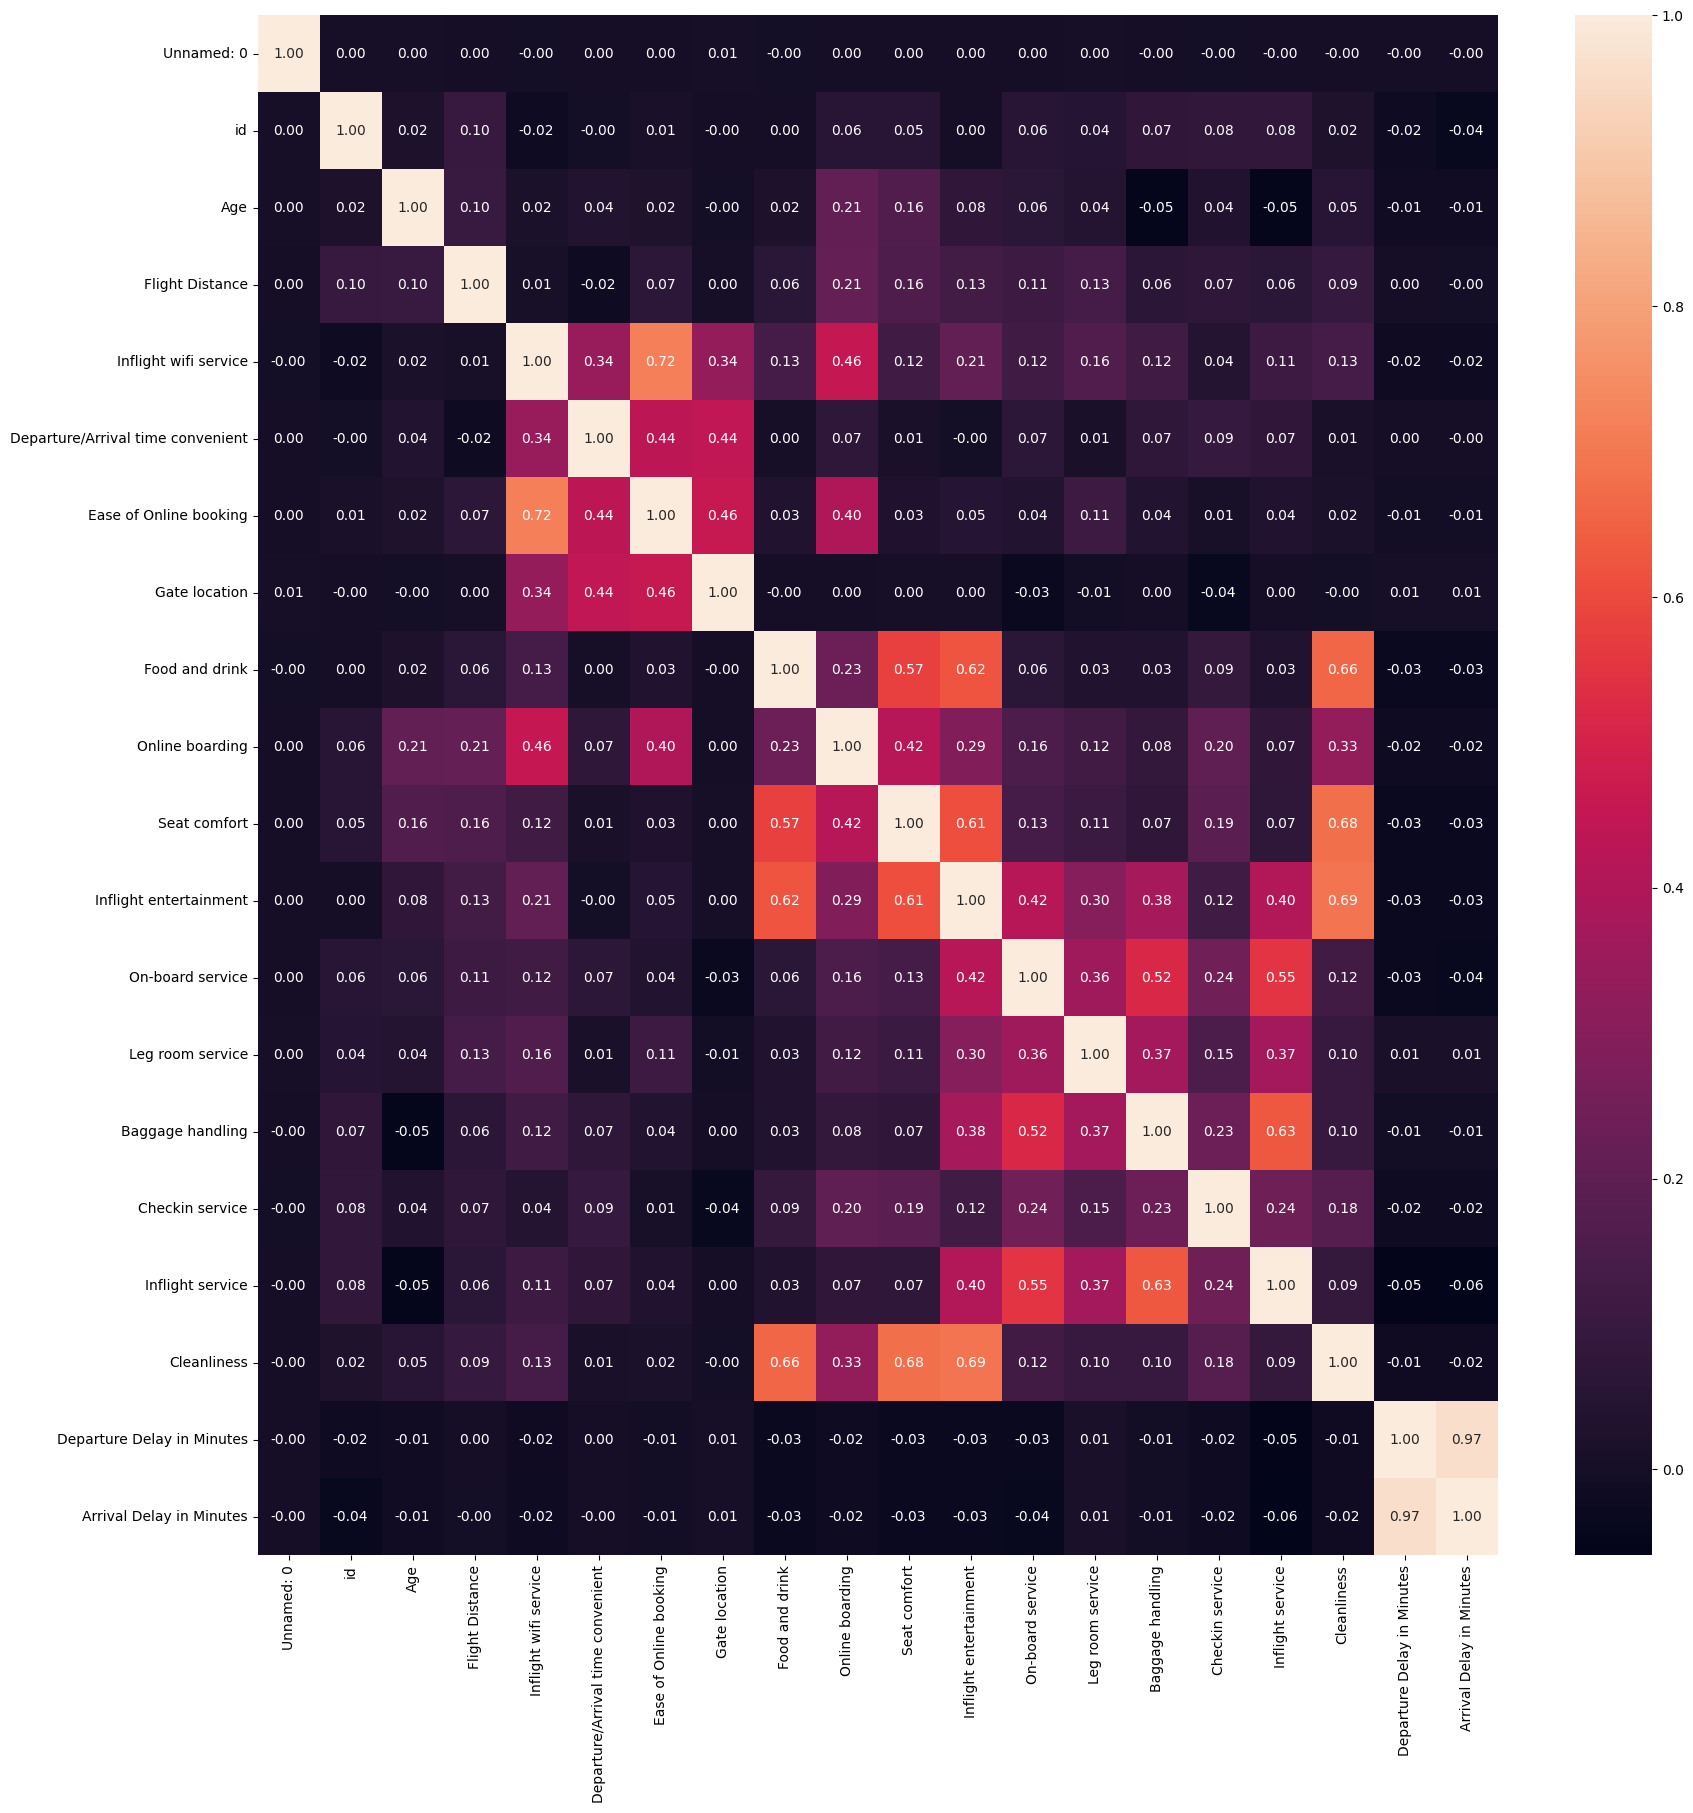

In [9]:
#Grafico de correlacion para analisis multivariado
plt.figure(figsize=(20, 20))
sb.heatmap(data = data.corr(numeric_only=True), annot=True, fmt='.2f')

In [10]:
#6. Preparacion de los datos
#-Activar las decisiones de ignorar variables
#-Transformacion de variables para qeu sean entemdibles por el modelo

data_mod = data.drop(['Unnamed: 0','id', 'Customer Type', 'Arrival Delay in Minutes'], axis = 1)
data_mod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype 
---  ------                             --------------   ----- 
 0   Gender                             103904 non-null  object
 1   Age                                103904 non-null  int64 
 2   Type of Travel                     103904 non-null  object
 3   Class                              103904 non-null  object
 4   Flight Distance                    103904 non-null  int64 
 5   Inflight wifi service              103904 non-null  int64 
 6   Departure/Arrival time convenient  103904 non-null  int64 
 7   Ease of Online booking             103904 non-null  int64 
 8   Gate location                      103904 non-null  int64 
 9   Food and drink                     103904 non-null  int64 
 10  Online boarding                    103904 non-null  int64 
 11  Seat comfort                       103904 non-null  

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline

num_col = data_mod.select_dtypes(include = ['int64', 'float64']).columns.to_list()
cat_col = data_mod.select_dtypes(include = ['object']).columns.to_list()

num_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])
cat_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

#Diseno transformador de columnas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_col),
        ('cat', cat_transformer, cat_col)
    ],
    remainder='passthrough'
)   

In [12]:
data_pre = preprocessor.fit_transform(data_mod)
data_pre

array([[0.07692308, 0.08663166, 0.6       , ..., 1.        , 1.        ,
        0.        ],
       [0.23076923, 0.04119548, 0.6       , ..., 0.        , 1.        ,
        0.        ],
       [0.24358974, 0.2243538 , 0.4       , ..., 0.        , 0.        ,
        1.        ],
       ...,
       [0.29487179, 0.39660743, 0.2       , ..., 0.        , 1.        ,
        0.        ],
       [0.19230769, 0.19567851, 0.2       , ..., 0.        , 1.        ,
        0.        ],
       [0.25641026, 0.34168013, 0.2       , ..., 0.        , 1.        ,
        0.        ]], shape=(103904, 26))

In [13]:
cod_cat = preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(cat_col)
labels = np.concatenate((num_col, cod_cat))
data_pro = pd.DataFrame(data_pre, columns=labels)
data_pro.head()

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Departure Delay in Minutes,Gender_Female,Gender_Male,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus,satisfaction_neutral or dissatisfied,satisfaction_satisfied
0,0.076923,0.086632,0.6,0.8,0.6,0.2,1.0,0.6,1.0,1.0,...,0.015704,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
1,0.230769,0.041195,0.6,0.4,0.6,0.6,0.2,0.6,0.2,0.2,...,0.000628,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.243590,0.224354,0.4,0.4,0.4,0.4,1.0,1.0,1.0,1.0,...,0.000000,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.230769,0.107229,0.4,1.0,1.0,1.0,0.4,0.4,0.4,0.4,...,0.006910,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.692308,0.036955,0.6,0.6,0.6,0.6,0.8,1.0,1.0,0.6,...,0.000000,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


In [27]:
#seed 25
data
data_pro_sample = data_pro.sample(3000,random_state=25)

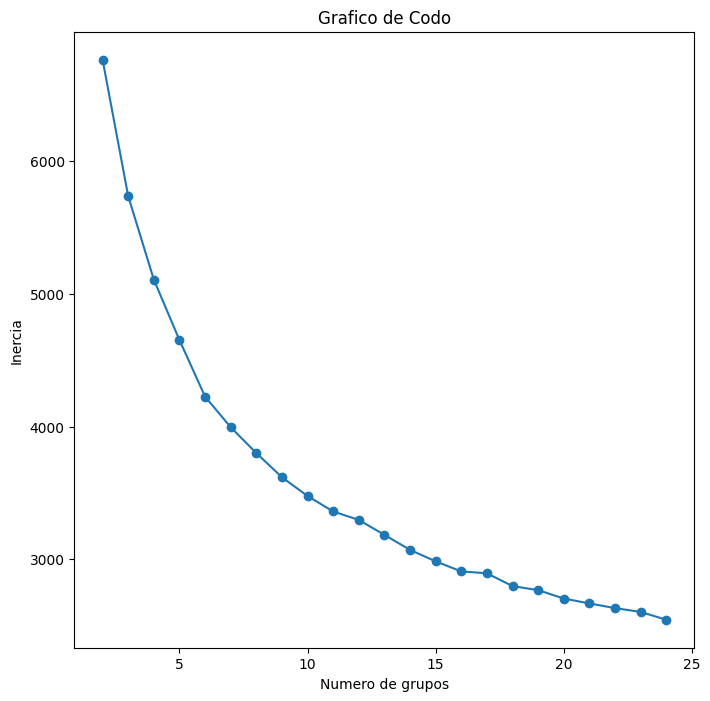

In [28]:
#7. Construccion del modelo
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#Definir el numero de clusters
range_k = range(2, 25)
inertia = []

for n_clusters in range_k:
    kmeans_model = KMeans(n_clusters=n_clusters,
                           n_init=20,
                           random_state=123)
    kmeans_model.fit(data_pro_sample)
    inertia.append(kmeans_model.inertia_)

plt.figure(figsize=(8,8))
plt.plot(range_k,inertia,marker = 'o')
plt.title('Grafico de Codo')
plt.xlabel('Numero de grupos')
plt.ylabel('Inercia')
plt.show()

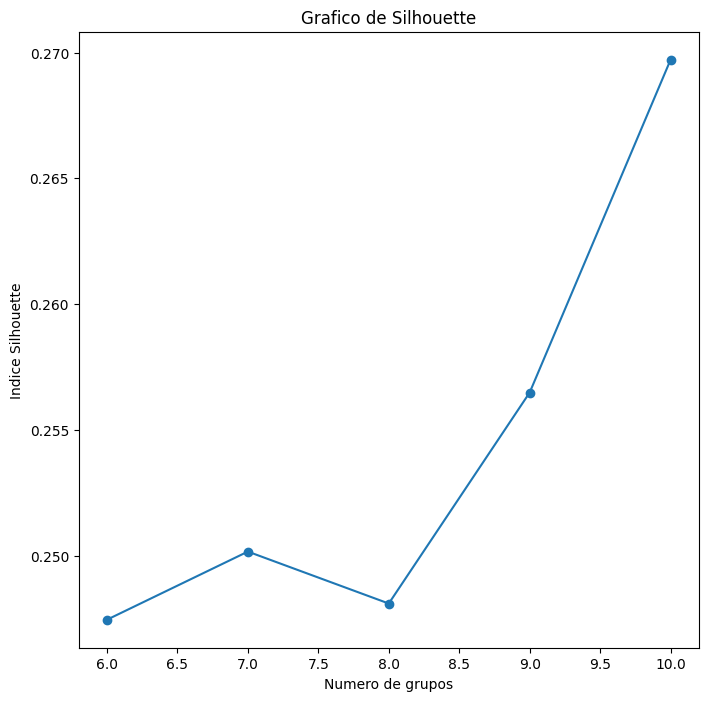

In [29]:
#Busqueda fina de k

range_k = range (6,11)
sil_score = []
for n_clusters in range_k:
    kmeans_model = KMeans(n_clusters=n_clusters,
                         n_init=20,
                         random_state=123)
    
    kmeans_model.fit(data_pro_sample)
    cluster_label = kmeans_model.fit_predict(data_pro_sample)
    sil_avg = silhouette_score(data_pro_sample,cluster_label)
    sil_score.append(sil_avg)


plt.figure(figsize=(8,8))
plt.plot(range_k,sil_score,marker = 'o')
plt.title('Grafico de Silhouette')
plt.xlabel('Numero de grupos')
plt.ylabel('Indice Silhouette')
plt.show()


In [30]:
kmeans_model_final = KMeans(n_clusters=10,n_init=20, random_state=123)
kmeans_model_final.fit(data_pro_sample)

,n_clusters,10
,init,'k-means++'
,n_init,20
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,123
,copy_x,True
,algorithm,'lloyd'


In [31]:
#Jerarquico Aglomerativo

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram

#Función para dibujar el dendrograma
def dibujarDendrograma(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count
 
    linkage_matrix = np.column_stack([model.children_, model.distances_, counts]).astype(float)
 
    # Plot
    dendrogram(linkage_matrix, **kwargs)

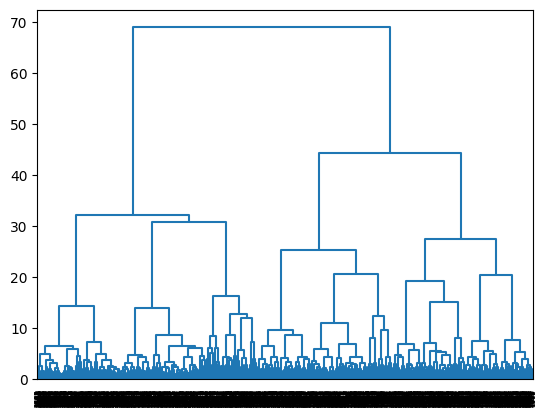

In [32]:
#Varianza
h_clust_ward = AgglomerativeClustering(metric='euclidean', linkage='ward' , distance_threshold=0, n_clusters=None)
h_clust_ward.fit(X = data_pro_sample)
dibujarDendrograma(h_clust_ward, color_threshold=0)

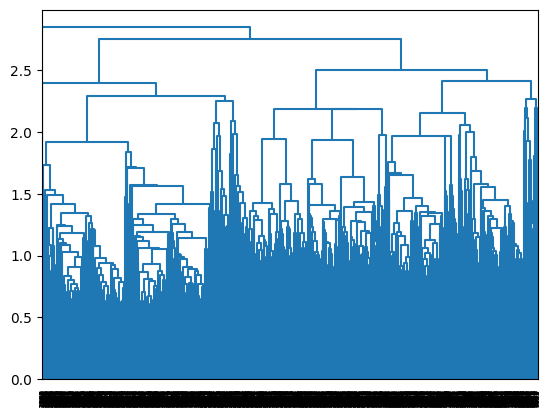

In [33]:
#Promedio 
h_clust_avg = AgglomerativeClustering(metric='euclidean', linkage='average' , distance_threshold=0, n_clusters=None)
h_clust_avg.fit(X = data_pro_sample)    
dibujarDendrograma(h_clust_avg, color_threshold=0)

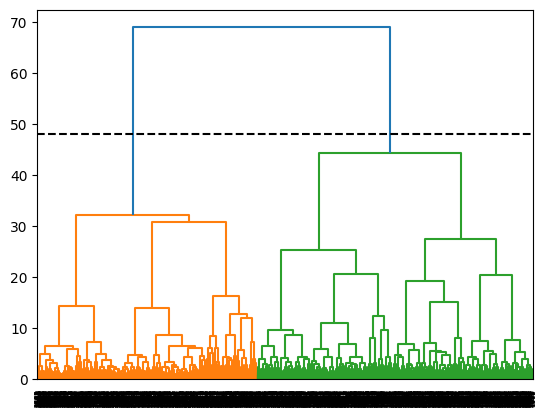

In [35]:
dendrogram_prum = 48
dibujarDendrograma(h_clust_ward, color_threshold=dendrogram_prum)
plt.axhline(y=dendrogram_prum, c='black', linestyle='--')
plt.show()

In [44]:
h_clust_final = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
h_clust_final.fit(data_pro_sample)

,n_clusters,2
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


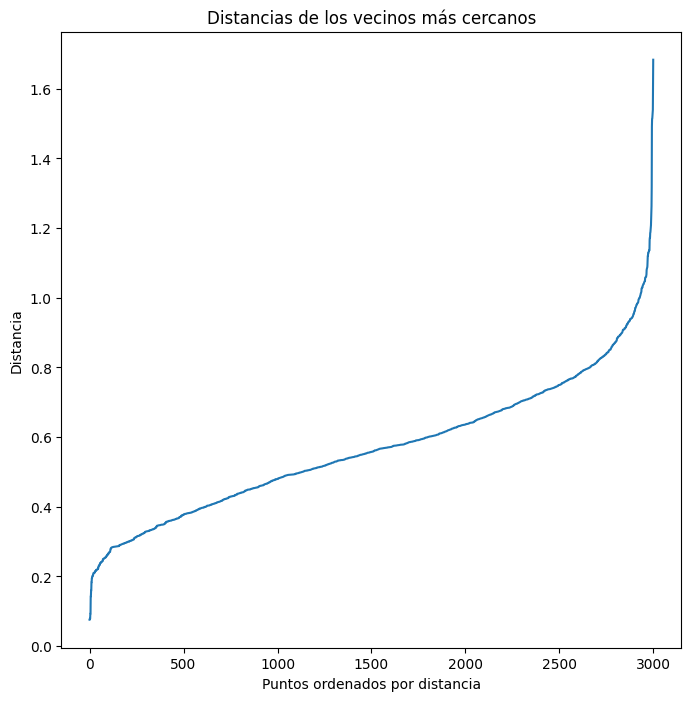

In [36]:
#BDScan
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from itertools import product 

neighbors = NearestNeighbors(n_neighbors=3)
neighbors_fit = neighbors.fit(data_pro_sample)
distances, indices = neighbors_fit.kneighbors(data_pro_sample)
distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.figure(figsize=(8, 8))
plt.plot(distances)
plt.title('Distancias de los vecinos más cercanos')
plt.xlabel('Puntos ordenados por distancia')
plt.ylabel('Distancia')
plt.show()


In [37]:
eps_values = np.arange(1.0, 1.7, 0.1)
min_samples = np.arange(2, 10)
dbscan_params = list(product(eps_values, min_samples))
sil_scores = []
for p in dbscan_params:
    y_pred = DBSCAN(eps=p[0], min_samples=p[1]).fit_predict(data_pro_sample)
    sil_scores.append(silhouette_score(data_pro_sample, y_pred))

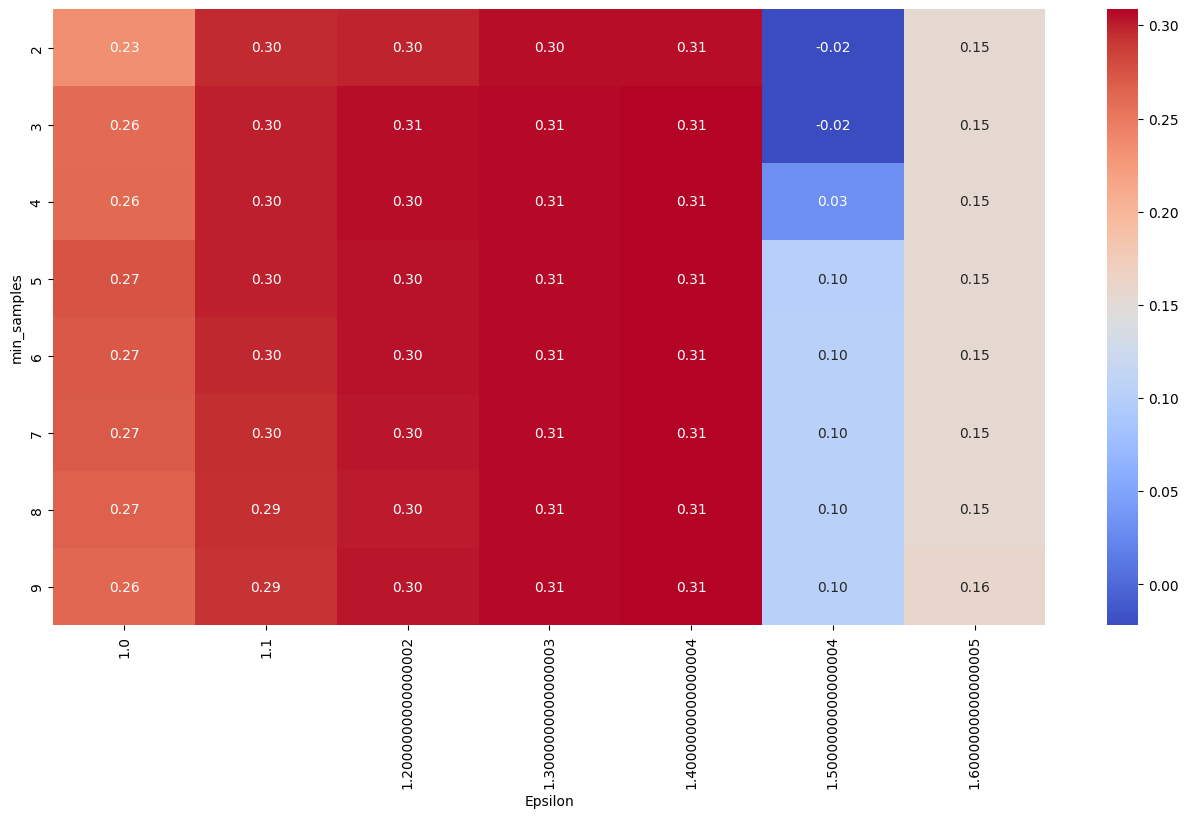

In [38]:
df_params_adj = pd.DataFrame(dbscan_params, columns=['Epsilon', 'min_samples'])
df_params_adj['Silhouette Score'] = sil_scores
pivot_table = pd.pivot_table(df_params_adj,columns='Epsilon', index='min_samples', values='Silhouette Score')
plt.figure(figsize=(16, 8))
sb.heatmap(pivot_table, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

In [39]:
dbscan_final = DBSCAN(eps=1.2, min_samples=3)
dbscan_final.fit(data_pro_sample)

,eps,1.2
,min_samples,3
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


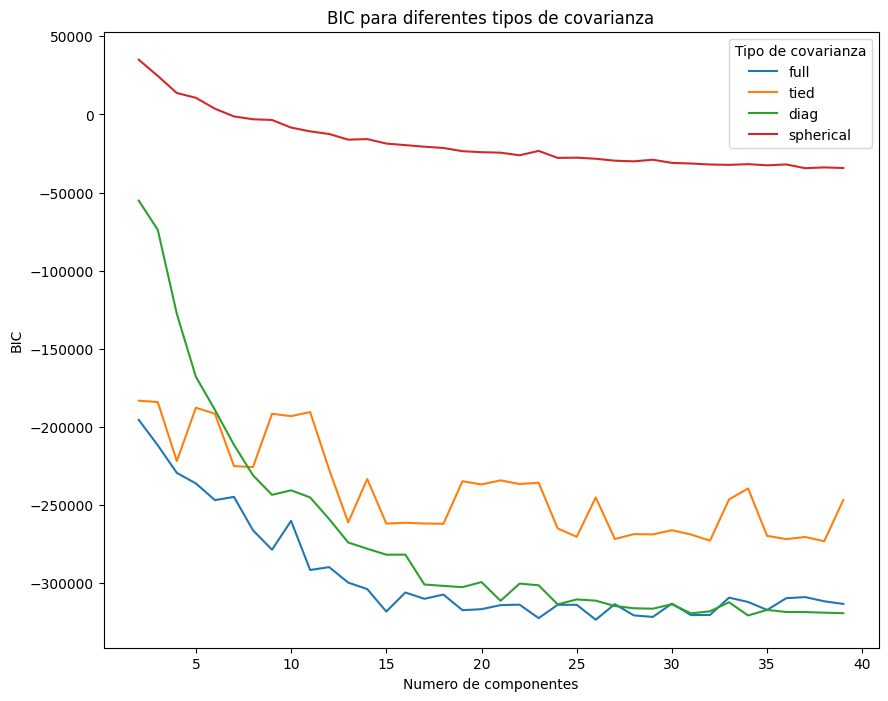

In [45]:
#Gaussian Mixture Model
from sklearn.mixture import GaussianMixture
fig, ax = plt.subplots(figsize=(10, 8))
n_gauss = range(2,40)
var_types = ['full', 'tied', 'diag', 'spherical']
for covariance_type in var_types:
    valor_bic = []
    for n in n_gauss:
        modelo = GaussianMixture(n_components=n, covariance_type=covariance_type)
        modelo = modelo.fit(data_pro_sample)
        valor_bic.append(modelo.bic(data_pro_sample))
    ax.plot(n_gauss, valor_bic, label=covariance_type)
ax.set_title('BIC para diferentes tipos de covarianza')
ax.set_xlabel('Numero de componentes')
ax.set_ylabel('BIC')
ax.legend(title='Tipo de covarianza')
plt.show()




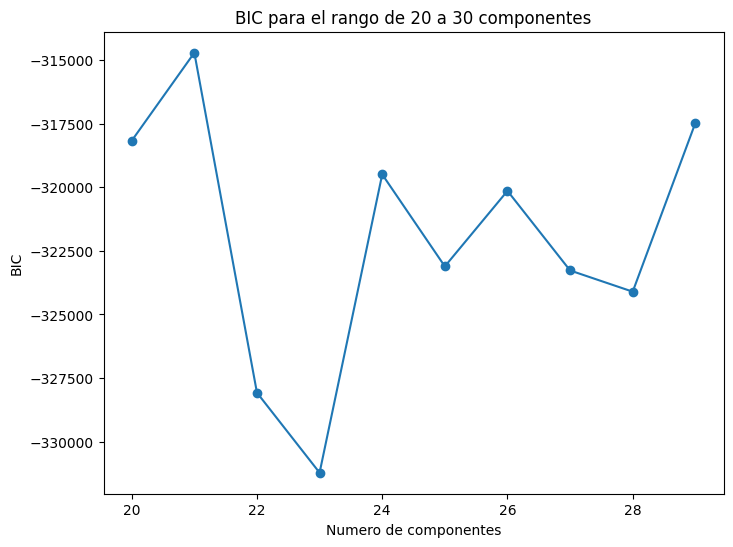

In [47]:
#Saber el valor BIC para el rango de 20 a 30 componentes
n_gauss = range(20, 30)
valor_bic = []
for n in n_gauss:
    modelo = GaussianMixture(n_components=n, covariance_type='full')
    modelo = modelo.fit(data_pro_sample)
    valor_bic.append(modelo.bic(data_pro_sample))
plt.figure(figsize=(8, 6))
plt.plot(n_gauss, valor_bic, marker='o')
plt.title('BIC para el rango de 20 a 30 componentes')
plt.xlabel('Numero de componentes')
plt.ylabel('BIC')
plt.show()


In [48]:
gmm_final = GaussianMixture(n_components=23, covariance_type='full')
gmm_final.fit(data_pro_sample)

,n_components,23
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,None


In [49]:
#8.Evaluacion del modelo
from sklearn.metrics import silhouette_score

labels_kmeans = kmeans_model_final.predict(data_pro_sample)
labels_h_clust = h_clust_final.fit_predict(data_pro_sample)
labels_dbscan = dbscan_final.fit_predict(data_pro_sample)
labels_gmm = gmm_final.predict(data_pro_sample)

sil_kmeans = silhouette_score(data_pro_sample, labels_kmeans)
sil_h_clust = silhouette_score(data_pro_sample, labels_h_clust)
sil_dbscan = silhouette_score(data_pro_sample, labels_dbscan)
sil_gmm = silhouette_score(data_pro_sample, labels_gmm)

print(f'Silhouette Score KMeans: {sil_kmeans:.4f}')
print(f'Silhouette Score Hierarchical Clustering: {sil_h_clust:.4f}')
print(f'Silhouette Score DBSCAN: {sil_dbscan:.4f}')
print(f'Silhouette Score GMM: {sil_gmm:.4f}')



Silhouette Score KMeans: 0.2697
Silhouette Score Hierarchical Clustering: 0.2452
Silhouette Score DBSCAN: 0.3056
Silhouette Score GMM: 0.0969


In [ ]:
np.unique(labels_dbscan)

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19, 20, 21, 22])

In [53]:
data_pro_sample['DBScan'] = labels_dbscan
data_pro_sample


,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Gender_Female,Gender_Male,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus,satisfaction_neutral or dissatisfied,satisfaction_satisfied,DBScan
39729,0.435897,0.208805,0.6,0.8,0.6,0.6,1.0,0.6,1.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0
79045,0.307692,0.191640,0.4,1.0,0.4,0.8,0.8,0.4,0.8,0.8,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1
49541,0.628205,0.074313,1.0,0.8,0.8,0.8,0.8,0.6,0.8,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,2
12516,0.346154,0.425081,0.8,0.8,1.0,0.8,0.2,0.8,0.8,0.8,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,3
82204,0.551282,0.176898,1.0,0.2,0.2,0.2,0.4,0.4,0.8,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63900,0.782051,0.045638,0.0,0.8,0.0,0.6,1.0,0.0,1.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,22
42466,0.358974,0.223546,0.2,0.8,0.2,0.4,1.0,0.2,1.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1
15206,0.205128,0.120557,0.8,0.8,0.8,0.6,0.4,0.8,0.4,0.4,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,6
49787,0.461538,0.103393,0.8,1.0,0.8,0.6,0.6,0.6,0.8,0.6,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0


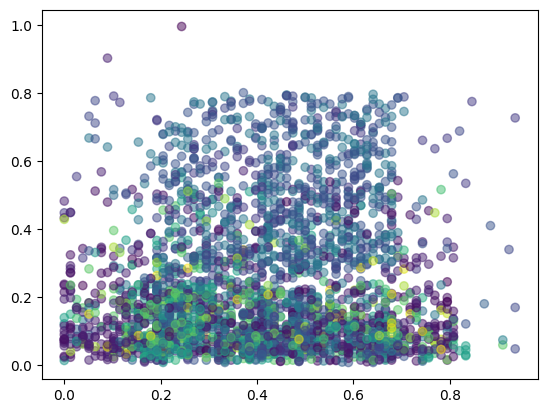

In [54]:
plt.scatter(data=data_pro_sample, x='Age', y='Flight Distance', c='DBScan', cmap='viridis', alpha=0.5)

In [55]:
data_pro_sample.DBScan.value_counts()

DBScan
 8     521
 5     504
 1     342
 0     323
 12    216
 16    198
 4     192
 3     173
 2      82
 6      75
 15     54
 14     44
 11     38
 7      31
 18     31
 19     30
 9      27
-1      25
 17     25
 13     22
 21     21
 10     10
 22     10
 20      6
Name: count, dtype: int64